# Przewidywanie cen samochodów na polskim rynku wtórnym

## 1. Wybór zestawu danych
**Zbiór danych:** [Car Prices Poland](https://www.kaggle.com/datasets/aleksandrglotov/car-prices-poland/data)

**Uzasadnienie wyboru:** 
Zbiór ten zawiera rzeczywiste dane o ogłoszeniach motoryzacyjnych w Polsce. Jest adekwatny do rozwiązania klasycznego problemu biznesowego: optymalizacji i automatyzacji wyceny pojazdów używanych. Zawiera różnorodne typy danych, co stwarza doskonałe warunki do zastosowania i porównania różnych metod uczenia maszynowego.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style="whitegrid")
np.random.seed(42)
df = pd.DataFrame({
    'mark': np.random.choice(['Audi', 'BMW', 'Toyota', 'Ford'], 1000),
    'year': np.random.randint(2000, 2023, 1000),
    'mileage': np.random.randint(10000, 300000, 1000),
    'vol_engine': np.random.randint(1000, 3000, 1000),
    'fuel': np.random.choice(['Gasoline', 'Diesel', 'LPG'], 1000),
    'price': np.random.randint(10000, 200000, 1000)
})

display(df.head())

,mark,year,mileage,vol_engine,fuel,price
0,Toyota,2021,87475,1883,LPG,90201
1,Ford,2016,162499,1213,LPG,18640
2,Audi,2008,299227,2678,Diesel,171121
3,Toyota,2000,228118,1375,Diesel,146690
4,Toyota,2020,133786,1743,Diesel,197125


## 2. Analiza zbioru danych
W tej sekcji przeprowadzamy eksploracyjną analizę danych (EDA), gdzie sprawdziliśmy:
* Typy zmiennych i podstawowe statystyki opisowe.
* Występowanie braków w danych.
* Rozkłady poszczególnych cech.
* Korelacje pomiędzy zmiennymi numerycznymi.

In [11]:
print("--- INFORMACJE O ZBIORZE ---")
df.info()

print("\n--- BRAKI W DANYCH ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.any() else "Brak pustych wartości w zbiorze.")

print("\n--- STATYSTYKI OPISOWE ---")
display(df.describe())

display(df.describe(include=['object']))

--- INFORMACJE O ZBIORZE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   mark        1000 non-null   object
 1   year        1000 non-null   int32 
 2   mileage     1000 non-null   int32 
 3   vol_engine  1000 non-null   int32 
 4   fuel        1000 non-null   object
 5   price       1000 non-null   int32 
dtypes: int32(4), object(2)
memory usage: 31.4+ KB

--- BRAKI W DANYCH ---
Brak pustych wartości w zbiorze.

--- STATYSTYKI OPISOWE ---


,year,mileage,vol_engine,price
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,2010.83700,157879.654000,2040.631000,107284.467000
std,6.71368,82584.092774,582.208001,56335.830209
min,2000.00000,11969.000000,1000.000000,10192.000000
25%,2005.00000,86310.750000,1532.000000,56979.750000
50%,2011.00000,158076.500000,2049.500000,106066.000000
75%,2017.00000,231563.250000,2570.500000,159004.250000
max,2022.00000,299910.000000,2999.000000,199919.000000


,mark,fuel
count,1000,1000
unique,4,3
top,Ford,Gasoline
freq,280,349


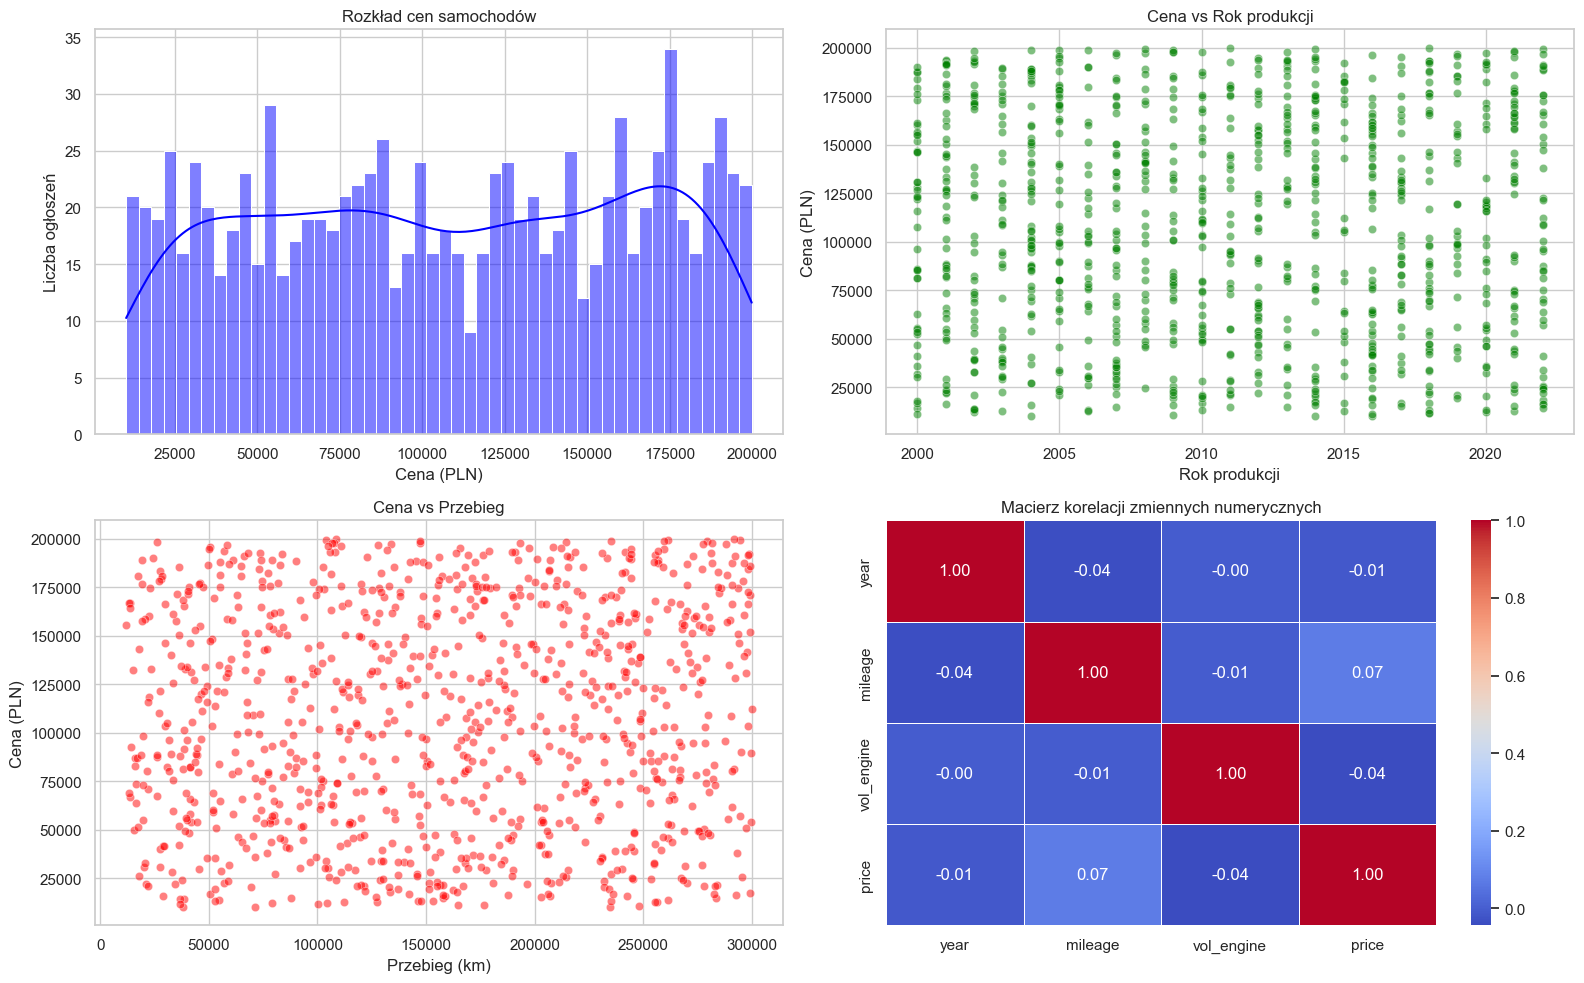

In [12]:
plt.figure(figsize=(16, 10))

#Rozkład cen samochodów
plt.subplot(2, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Rozkład cen samochodów')
plt.xlabel('Cena (PLN)')
plt.ylabel('Liczba ogłoszeń')

#Zależność ceny od roku produkcji
plt.subplot(2, 2, 2)
sns.scatterplot(x='year', y='price', data=df, alpha=0.5, color='green')
plt.title('Cena vs Rok produkcji')
plt.xlabel('Rok produkcji')
plt.ylabel('Cena (PLN)')

#Zależność ceny od przebiegu
plt.subplot(2, 2, 3)
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.5, color='red')
plt.title('Cena vs Przebieg')
plt.xlabel('Przebieg (km)')
plt.ylabel('Cena (PLN)')

#Macierz korelacji
plt.subplot(2, 2, 4)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji zmiennych numerycznych')

plt.tight_layout()
plt.show()

## 3. Sformułowanie hipotezy

**Problem biznesowy:** Ręczna wycena samochodów na rynku wtórnym jest czasochłonna i podatna na błędy poznawcze sprzedających np. zawyżanie wartości sentymentalnej. Firmy ubezpieczeniowe, komisy oraz platformy sprzedażowe często potrzebują zautomatyzowanych i obiektywnych narzędzi wyceny.

**Hipoteza główna:**
Na podstawie historycznych danych ogłoszeniowych możliwe jest zbudowanie modelu uczenia maszynowego, który z dużą dokładnością przewidzi rynkową cenę samochodu w Polsce. 

**Hipotezy pomocnicze:**
1. Zmiennymi o największej mocy predykcyjnej będą *rok produkcji* (korelacja dodatnia) oraz *przebieg* (korelacja ujemna).
2. Marka pojazdu znacząco wpływa na tempo utraty wartości w czasie.


## 4. Aktualny stan wiedzy

Przewidywanie cen samochodów używanych to klasyczny problem regresyjny w uczeniu maszynowym, chętnie badany ze względu na dużą dostępność danych z portali ogłoszeniowych.

* **Stosowane podejścia:** Najprostszym historycznym modelem jest *Wieloraka Regresja Liniowa*. Mimo że jest łatwa w interpretacji, często nie radzi sobie z nieliniowymi zależnościami.
* **Nowoczesne rozwiązania:** Obecnie stanem wiedzy dla tego typu danych są algorytmy oparte na drzewach decyzyjnych. Algorytmy takie jak *Random Forest*, *XGBoost* czy *LightGBM* dominują w publikacjach naukowych i konkursach na platformie Kaggle. Świetnie radzą sobie z ogromną liczbą zmiennych kategorycznych.
* **Wyzwania:** Głównym problemem w aktualnych badaniach nad tym obszarem jest jakość danych. Ukryte wady pojazdów, fałszowane przebiegi czy błędy w opisach ogłoszeń, które stanowią szum informacyjny trudny do wychwycenia przez modele oparte wyłącznie na twardych metrykach. Z tego powodu nowsze podejścia próbują czasem analizować również zdjęcia aut za pomocą sieci konwolucyjnych jako dodatkowe wejście dla modelu wyceny.